In [2]:
import numpy as np 
import scipy
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [3]:
def rmvt(mu, Sigma, nu, n):
    d=len(mu)
    Z = np.random.multivariate_normal(mean= np.zeros(d), cov= Sigma, size= n)
    W = np.random.chisquare(df= nu, size= n)
    X = mu + np.sqrt(nu/W.reshape(-1,1))*Z
    return X

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

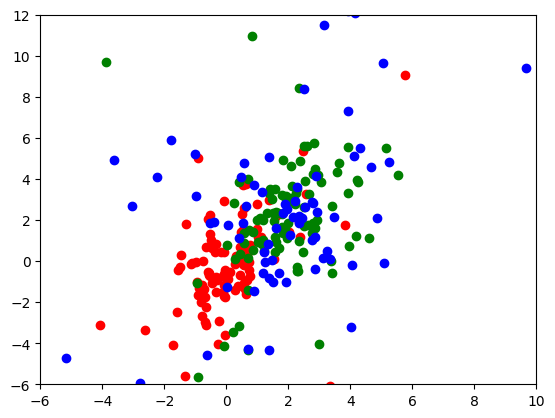

In [4]:
mu1 = np.array([0,0])
mu2 = np.array([2,2])
Sigma1 = np.array([[1,1], 
                   [1,4]])
Sigma2 = 4*Sigma1

MVS1 = rmvt(mu1, Sigma1, 5, 100)
MVS2 = rmvt(mu2, Sigma1, 3, 100)
MVS3 = rmvt(mu2, Sigma2, 1, 100)

# affichage
plt.figure()
plt.scatter(MVS1[:,0], MVS1[:,1], color= "red")
plt.scatter(MVS2[:,0], MVS2[:,1], color= "green")
plt.scatter(MVS3[:,0], MVS3[:,1], color= "blue")
plt.xlim(-6, 10)
plt.ylim(-6, 12)
plt.plot


In [5]:
Sigma3 = np.array([[1,1,1],
                   [1,4,4],
                   [1,4,9]])
mu3 = np.zeros(3)
data = rmvt(mu3, Sigma3, 5, 1000)

# matrice de projection
p = np.array([[1,1,1,1,1],
              [1,-1,1,-1,0],
              [0,-1,-1,0,2]])
norm = np.linalg.norm(p, axis=0) 

# projection
p_normalized = p/norm
projection = data @ p_normalized

# shift
shift = np.array([1, 2, 3, 4, 5])
projection_shifted = projection + shift

# ajout de bruit
noise = np.random.multivariate_normal(mean=np.zeros(5), cov=0.025*np.eye(5), size=1000)
projection_final = projection_shifted + noise

## PCA 

[2.75009231e+01 5.26353401e+00 1.85930716e+00 2.51811370e-02
 2.46797945e-02]
[165.75108497  72.51393297  43.09811896   5.01557134   4.96539169]
[[ 0.33573854 -0.59063249 -0.1448026  -0.2091841   0.68826384]
 [ 0.63230654  0.03985454  0.72373019 -0.20274733 -0.1835979 ]
 [ 0.24790076  0.44956251  0.07927364  0.69754295  0.49354664]
 [ 0.59910218 -0.17609698 -0.55009868  0.29520182 -0.46937592]
 [ 0.25901711  0.64532804 -0.38256236 -0.58431605  0.16935952]]


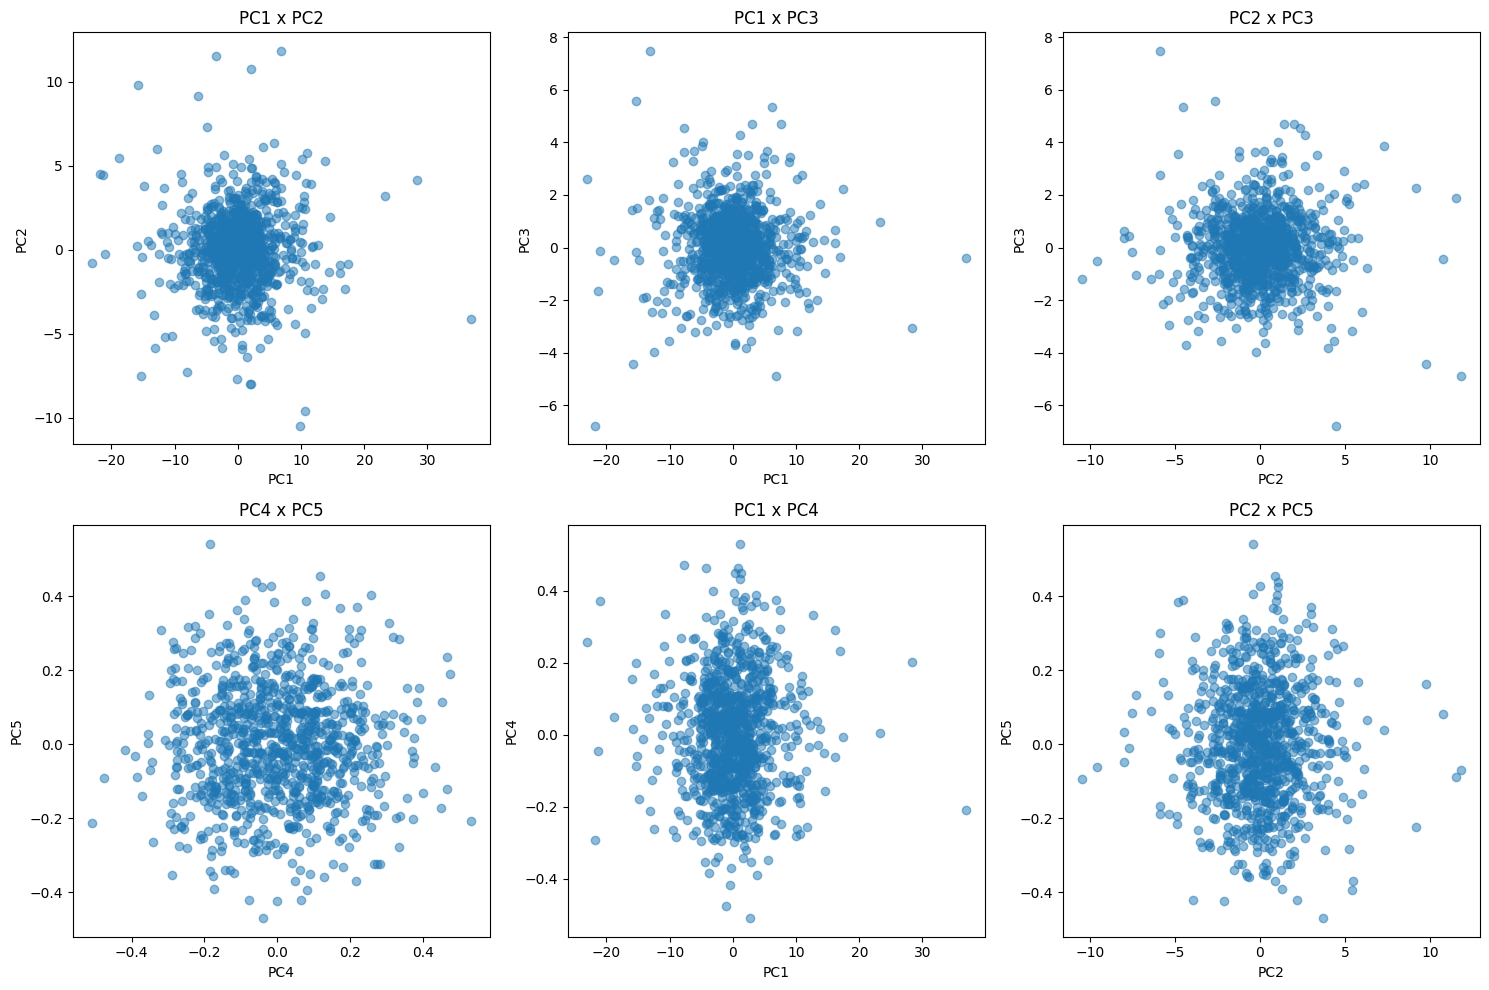

In [6]:
# PCA
pca = PCA(n_components=5)
data_pca = pca.fit_transform(projection_final)

# variance & singular values & full principal components
print(pca.explained_variance_)
print(pca.singular_values_)
print(pca.components_)

# affichage
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

# PC1 x PC2
axs[0, 0].scatter(data_pca[:, 0], data_pca[:, 1], alpha=0.5)
axs[0, 0].set_xlabel('PC1')
axs[0, 0].set_ylabel('PC2')
axs[0, 0].set_title('PC1 x PC2')

# PC1 x PC3
axs[0, 1].scatter(data_pca[:, 0], data_pca[:, 2], alpha=0.5)
axs[0, 1].set_xlabel('PC1')
axs[0, 1].set_ylabel('PC3')
axs[0, 1].set_title('PC1 x PC3')

# PC2 x PC3
axs[0, 2].scatter(data_pca[:, 1], data_pca[:, 2], alpha=0.5)
axs[0, 2].set_xlabel('PC2')
axs[0, 2].set_ylabel('PC3')
axs[0, 2].set_title('PC2 x PC3')

# PC4 x PC5
axs[1, 0].scatter(data_pca[:, 3], data_pca[:, 4], alpha=0.5)
axs[1, 0].set_xlabel('PC4')
axs[1, 0].set_ylabel('PC5')
axs[1, 0].set_title('PC4 x PC5')

# PC1 x PC4
axs[1, 1].scatter(data_pca[:, 0], data_pca[:, 3], alpha=0.5)
axs[1, 1].set_xlabel('PC1')
axs[1, 1].set_ylabel('PC4')
axs[1, 1].set_title('PC1 x PC4')

# PC2 x PC5
axs[1, 2].scatter(data_pca[:, 1], data_pca[:, 4], alpha=0.5)
axs[1, 2].set_xlabel('PC2')
axs[1, 2].set_ylabel('PC5')
axs[1, 2].set_title('PC2 x PC5')

plt.tight_layout()
plt.show()


## Observations
Les premières composantes (PC1, PC2, PC3) sont celles qui expliquent le mieux la variance. Le graphe montre qu'elles traduisent le mieux la structure de nos données.  
Par contre, les 2 autres composantes (PC4, PC5) eux ne traduisent pas vraiment la structure, elles capturent plus le bruit.

## PCA via SVD

In [7]:
# SVD 
data_centere = projection_final - np.mean(projection_final, axis=0)
U, S, Vt = np.linalg.svd(data_centere)

#PCA : data_centered @ vecteur_propres
cov = np.cov(data_centere, rowvar=False)
valeurs_propres, vecteurs_propres = np.linalg.eigh(cov)

# comparaison 
print("Matrice Vt via SVD :\n", Vt)
print("Vecteurs propres via SVD :\n", vecteurs_propres[:, ::-1].T)

Matrice Vt via SVD :
 [[-0.33573854  0.59063249  0.1448026   0.2091841  -0.68826384]
 [-0.63230654 -0.03985454 -0.72373019  0.20274733  0.1835979 ]
 [-0.24790076 -0.44956251 -0.07927364 -0.69754295 -0.49354664]
 [-0.59910218  0.17609698  0.55009868 -0.29520182  0.46937592]
 [ 0.25901711  0.64532804 -0.38256236 -0.58431605  0.16935952]]
Vecteurs propres via SVD :
 [[-0.33573854  0.59063249  0.1448026   0.2091841  -0.68826384]
 [ 0.63230654  0.03985454  0.72373019 -0.20274733 -0.1835979 ]
 [ 0.24790076  0.44956251  0.07927364  0.69754295  0.49354664]
 [ 0.59910218 -0.17609698 -0.55009868  0.29520182 -0.46937592]
 [ 0.25901711  0.64532804 -0.38256236 -0.58431605  0.16935952]]


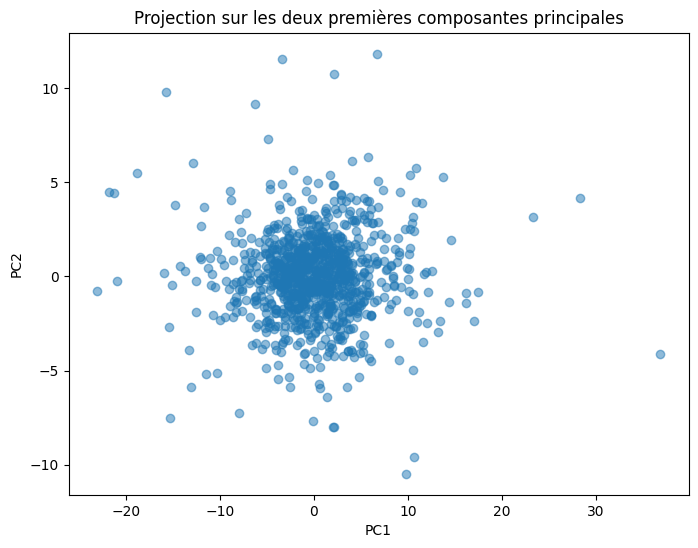

In [13]:
projection_final[-100:] = np.random.standard_cauchy(size=(100, projection_final.shape[1]))

plt.figure(figsize=(8, 6))
plt.scatter(data_pca[:, 0], data_pca[:, 1], alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Projection sur les deux premières composantes principales')
plt.show()

In [14]:
pca = PCA(5)
data_pca = pca.fit_transform(projection_final)

print("Explained variances:", pca.explained_variance_)
print("Singular values:", pca.singular_values_)
print("Principal components:\n", pca.components_)

Explained variances: [267.51417755  51.57410647  36.00149467  23.98234824  20.44834833]
Singular values: [516.95905386 226.98575366 189.64570435 154.78490202 142.92620468]
Principal components:
 [[-0.00928974  0.00844179 -0.00395683  0.99931488 -0.03459115]
 [ 0.47337728 -0.55716026 -0.33212895  0.02839803  0.5952901 ]
 [-0.53466591 -0.43862473  0.6246277   0.01375544  0.36247998]
 [-0.03967884  0.70031046  0.04474474  0.0185066   0.71108808]
 [ 0.69884591  0.08169934  0.7053459   0.00562253 -0.08599509]]


Non les composantes principales ne coincident plus avec celles précédentes. Les valeurs extrêmes de la loi de Cauchy perturbent fortement le PCA.

In [15]:
# Minimum covariance Determonant 
from sklearn.covariance import MinCovDet

mcd = MinCovDet().fit(projection_final)
print("MCD location (mean estimate):", mcd.location_)
print("MCD covariance matrix:\n", mcd.covariance_)

MCD location (mean estimate): [0.98378885 2.07159965 3.07395918 3.96432554 4.84638067]
MCD covariance matrix:
 [[ 3.3876457  -2.91093777  0.95461055 -1.39332805  3.38444218]
 [-2.91093777  5.67597131  1.33082583  2.36207057 -5.91575841]
 [ 0.95461055  1.33082583  2.0957404   0.01077498 -1.7119308 ]
 [-1.39332805  2.36207057  0.01077498  1.51129899 -1.74099375]
 [ 3.38444218 -5.91575841 -1.7119308  -1.74099375  7.4893423 ]]


In [16]:
# SVD sur la matrice de covariance robuste
from numpy.linalg import eigh

eigvals, eigvecs = eigh(mcd.covariance_)
# Ordonner par ordre décroissant
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

print("Valeurs propres (MCD):", eigvals)
print("Vecteurs propres (MCD):\n", eigvecs.T)

Valeurs propres (MCD): [15.31895718  3.51116108  1.27970559  0.02581397  0.02436087]
Vecteurs propres (MCD):
 [[-0.35312264  0.59345128  0.12209283  0.22264186 -0.67723255]
 [ 0.63075483  0.07494514  0.72618396 -0.18026086 -0.19155795]
 [ 0.23356314  0.44210486  0.05886004  0.70007006  0.50638816]
 [-0.52826967  0.31244709  0.45352328 -0.41657157  0.49405743]
 [-0.37925211 -0.59086286  0.49860037  0.50428828 -0.06434216]]
